<a href="https://colab.research.google.com/github/anhtin18/SGU26_Ml/blob/main/Ph%C3%A2n%20t%C3%ADch%20v%C3%A0%20Ti%E1%BB%81n%20x%E1%BB%AD%20l%C3%BD%20D%E1%BB%AF%20li%E1%BB%87u.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title ## Chương 3: Thuật toán Hồi quy, Giảm chiều dữ liệu & Phân cụm
# @markdown Chạy ô này để thiết lập môi trường và xem tóm tắt nội dung bài giảng.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import linear_model, decomposition, datasets
from sklearn.metrics import mean_squared_error
from sklearn.neural_network import MLPRegressor

def print_header(text):
    print(f"\n{'='*20} {text} {'='*20}")

print("Môi trường đã sẵn sàng!")

Môi trường đã sẵn sàng!



==================== 1. Chuẩn bị dữ liệu ====================


<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_16203/3126699353.py:6: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


Số lượng mẫu huấn luyện: 354
Số lượng mẫu kiểm tra: 152

==================== 2. Kết quả mô hình ====================
Linear Regression MSE: 23.7833
Ridge Regression MSE:  23.6869
MLP Regressor MSE:    19.9756


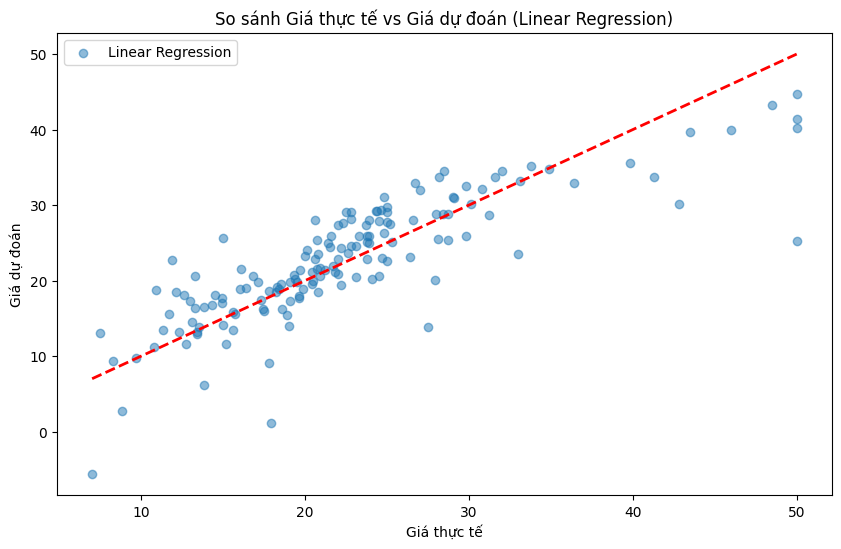

In [2]:
# @title Thực thi Hồi quy (Linear, Ridge, MLP)

# 1. Tải dữ liệu Boston Housing từ nguồn chính thức
print_header("1. Chuẩn bị dữ liệu")
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Chia tập dữ liệu: 70% huấn luyện, 30% kiểm tra
X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.3, random_state=309
)
print(f"Số lượng mẫu huấn luyện: {len(X_train)}")
print(f"Số lượng mẫu kiểm tra: {len(X_test)}")

# 2. Hồi quy tuyến tính (Linear Regression)
print_header("2. Kết quả mô hình")
lr = linear_model.LinearRegression().fit(X_train, y_train)
pred_lr = lr.predict(X_test)
print(f"Linear Regression MSE: {mean_squared_error(y_test, pred_lr):.4f}")

# 3. Ridge Regression (Điều chuẩn L2)
ridge = linear_model.Ridge(alpha=1.0).fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)
print(f"Ridge Regression MSE:  {mean_squared_error(y_test, pred_ridge):.4f}")

# 4. Mạng nơ-ron (MLP Regressor)
mlp = MLPRegressor(random_state=309, max_iter=2000, alpha=0.5).fit(X_train, y_train)
pred_mlp = mlp.predict(X_test)
print(f"MLP Regressor MSE:    {mean_squared_error(y_test, pred_mlp):.4f}")

# Trực quan hóa kết quả
plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred_lr, alpha=0.5, label='Linear Regression')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Giá thực tế')
plt.ylabel('Giá dự đoán')
plt.title('So sánh Giá thực tế vs Giá dự đoán (Linear Regression)')
plt.legend()
plt.show()


==================== Giảm chiều dữ liệu với PCA ====================
Kích thước ban đầu: (150, 4)
Kích thước sau PCA: (150, 2)


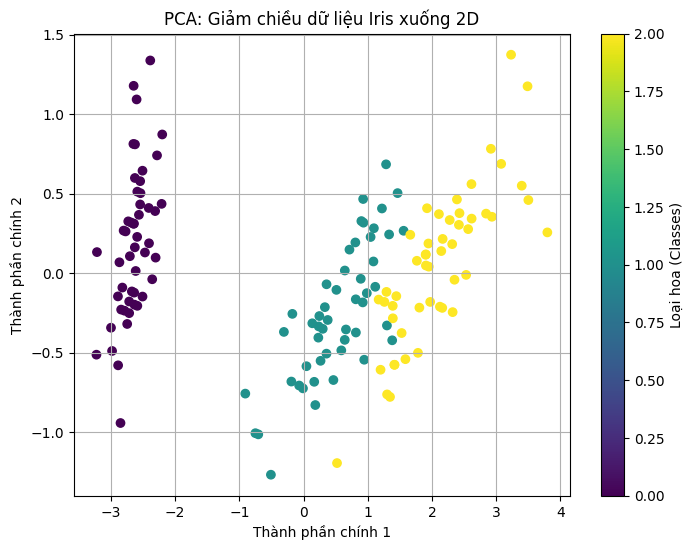

In [3]:
# @title Thực thi PCA trên tập dữ liệu Iris

print_header("Giảm chiều dữ liệu với PCA")
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Giảm xuống còn 2 chiều để vẽ đồ thị
pca = decomposition.PCA(n_components=2)
X_pca = pca.fit_transform(X)

print(f"Kích thước ban đầu: {X.shape}")
print(f"Kích thước sau PCA: {X_pca.shape}")

# Vẽ đồ thị 2D
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.colorbar(scatter, label='Loại hoa (Classes)')
plt.title('PCA: Giảm chiều dữ liệu Iris xuống 2D')
plt.xlabel('Thành phần chính 1')
plt.ylabel('Thành phần chính 2')
plt.grid(True)
plt.show()


==================== Phân cụm K-Means ====================


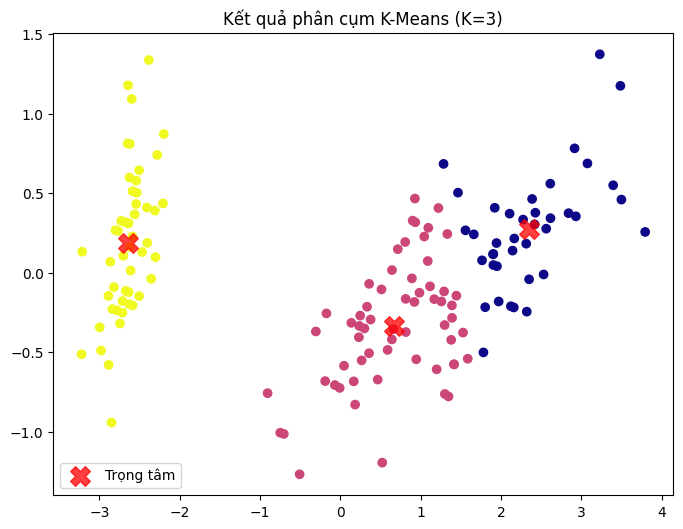

In [4]:
# @title Thực thi Phân cụm K-Means
from sklearn.cluster import KMeans

print_header("Phân cụm K-Means")
# Giả sử chúng ta phân cụm trên dữ liệu PCA của Iris ở trên
kmeans = KMeans(n_clusters=3, random_state=309, n_init='auto')
clusters = kmeans.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='plasma')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Trọng tâm')
plt.title('Kết quả phân cụm K-Means (K=3)')
plt.legend()
plt.show()